## Fig 6C

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(dplyr)
  require(tidyr)
  library(ggpubr)
})

source('../utilities/functions/label-and-color-maps.R')          

In [2]:
plasma <- readRDS('../../data/figure-inputs/olink/MM_Plasma_Olink_Final.rds')

In [3]:
### First split the healthy subjects  
### then extract only Flu Year 1 day 0 samples 
healthy = plasma[plasma$cohort.cohortGuid %in% c('BR1','BR2')]
healthy = healthy[sample.visitDetails =='Flu_Y1D0']

mm_treatment = plasma[sample.visitDetails %in% c('PreTx','PI2C','EI','ASCT60d', 'ASCT1y','ASCT2y')]

healthy$Cohort = 'Healthy'
mm_treatment$Cohort = 'NDMM'

plasma_treatment = rbind(healthy, mm_treatment)
plasma_treatment[plasma_treatment$sample.visitDetails =='Flu_Y1D0']$sample.visitDetails <- 'Healthy'

In [4]:
plasma_longitudinal_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_pairwise_deps.csv')
plasma_healthy_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_comparisons_to_healthy.csv')

In [5]:
make_protein_plot <- function(df, protlist, times, title, ncol = NULL) {
  plot_df <- df[olink.assay %in% protlist & sample.visitDetails %in% times]

  p <- ggplot(
    plot_df,
    aes(x = sample.visitDetails, y = olink.NPX_norm,
        group = subject.subjectGuid, fill = sample.visitDetails)
  ) +
    geom_line(alpha = 0.4) +
    geom_violin(aes(group = sample.visitDetails), alpha = 0.5, scale = "width") +
    geom_point(aes(color = sample.visitDetails), alpha = 0.7, size = 1.5) +
    facet_wrap(~olink.assay, scales = "free_y",
               ncol = if (!is.null(ncol)) ncol else length(protlist)) +
    scale_fill_manual(values = tp_color_map) +
    scale_color_manual(values = tp_color_map) +
    theme_classic(base_size = 20) +
    theme(
      axis.text.x = element_text(size = 20, angle = 45, hjust = 1),
      axis.text.y = element_text(size = 20),
      axis.title.y = element_text(size = 20),
      strip.text = element_text(size = 20, hjust = 0, face = "bold"),
      strip.background = element_blank(),
      legend.position = "none",
      plot.title = element_text(face = "bold", size = 18)
    ) +
    labs(x = "", y = "Olink NPX") +
    ggtitle(title)

  return(p)
}

plot_protein_groups_with_pvals <- function(
    prots = NULL,
    mat = plasma_treatment,
    timePoints = c('PreTx', 'PI2C', 'EI', 'Healthy'),
    healthy_pval_df,
    longitudinal_pval_df,
    tname = 'Plasma',
    ncol = NULL) {

  healthy_pval_df <- healthy_pval_df[olink.assay %in% prots & group1 %in% timePoints & group2 %in% timePoints]
  longitudinal_pval_df <- longitudinal_pval_df[olink.assay %in% prots & group1 %in% timePoints & group2 %in% timePoints]

  p <- make_protein_plot(mat, prots, timePoints, tname, ncol = ncol) +
    stat_pvalue_manual(
      healthy_pval_df[adjP < 0.05, ],
      xmin = "group1", xmax = "group2",
      y.position = "y.position", label = "label",
      col = "#006400", step.increase = 0.012,
      tip.length = 0.005, size = 6, bracket.size = 0.8
    ) +
    stat_pvalue_manual(
      longitudinal_pval_df[adjP < 0.05, ],
      xmin = "group1", xmax = "group2",
      y.position = "y.position", label = "label",
      col = "black", step.increase = 0.01,
      tip.length = 0.005, size = 6, bracket.size = 0.8
    )

  return(p)
}

In [6]:
create_summary_pval <- function(plasma_healthy_comparisons){
    
    pval_df <- plasma_healthy_comparisons
    setDT(pval_df)
    setDT(plasma_treatment)
    
    pval_df$olink.assay <- pval_df$Assay
    pval_df$group1 <- pval_df$Time1
    pval_df$group2 <- pval_df$Time2
    
    # 1. Remove duplicated comparisons
    pval_df <- unique( pval_df, by = c("olink.assay", "group1", "group2"))
    
    # 2. Create significance labels
    pval_df[, label := fifelse(
      adjP < 0.001, "***",
      fifelse(
        adjP < 0.01, "**",
        fifelse(adjP < 0.05, "*", "ns")
      ))]
    
    max_positions <- plasma_treatment[ , 
                                      list(y.position = max(olink.NPX_norm,
                                                            na.rm = TRUE)+0.5), 
                                      by = olink.assay]
    
    pval_df <- dplyr::left_join(pval_df, max_positions)
    
}
healthy_pval_df <- create_summary_pval(plasma_healthy_comparisons)
longitudinal_pval_df <- create_summary_pval(plasma_longitudinal_comparisons)
healthy_pval_df$y.position <- healthy_pval_df$y.position +2

Joining with `by = join_by(olink.assay)`


Joining with `by = join_by(olink.assay)`


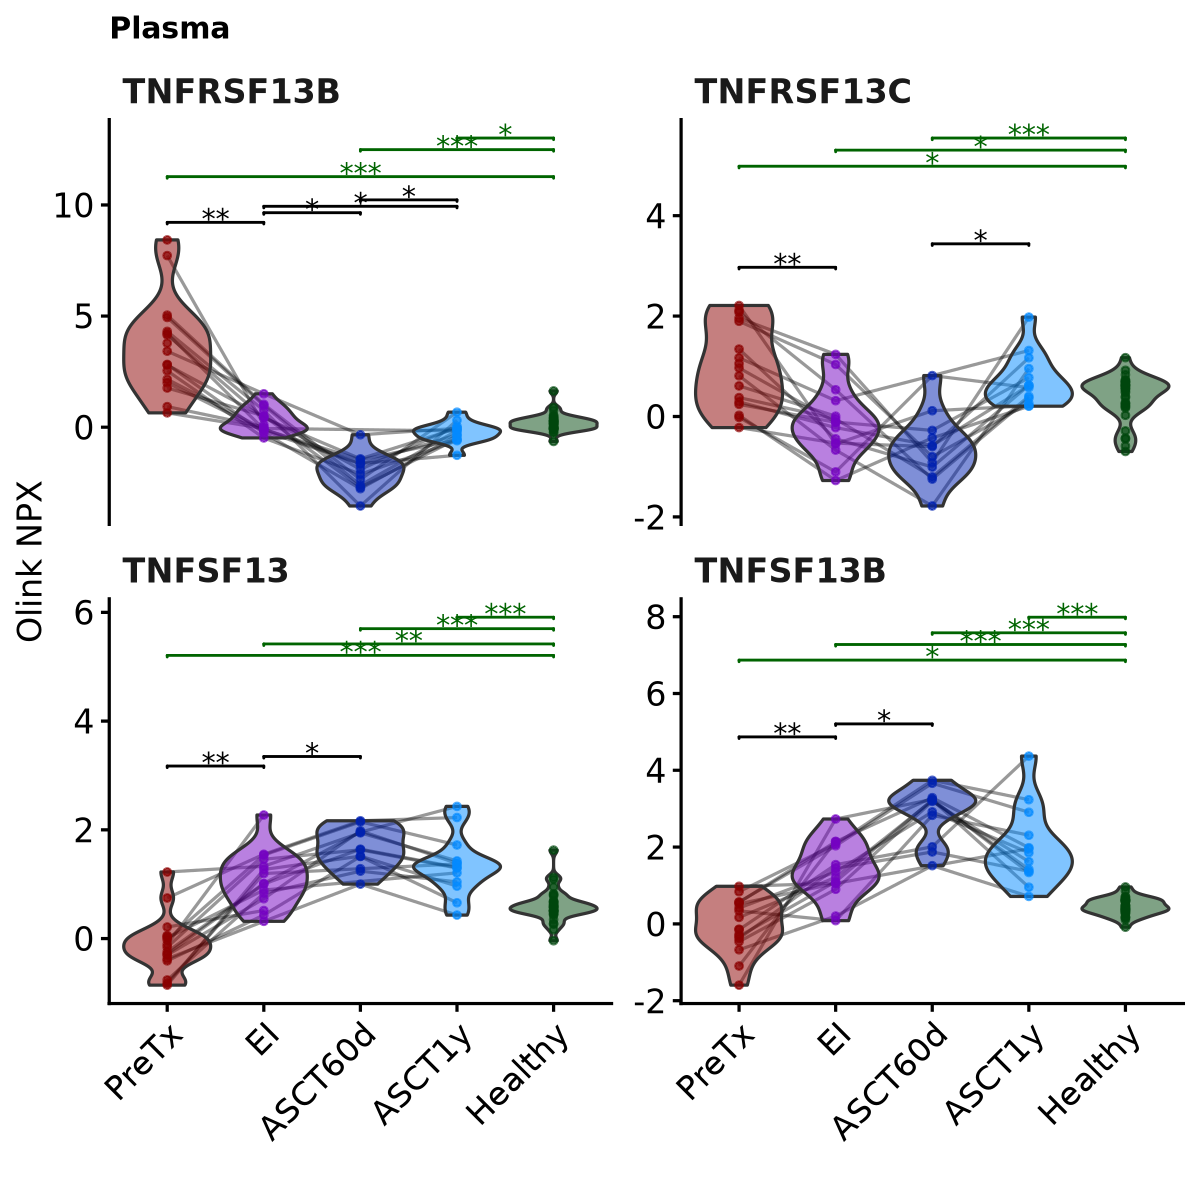

In [7]:
options(repr.plot.width = 10, repr.plot.height = 10)

p <- plot_protein_groups_with_pvals(
  prots = c('TNFRSF13C', 'TNFRSF13B', 'TNFSF13', 'TNFSF13B'),
  timePoints = c('PreTx', 'EI', 'ASCT60d', 'ASCT1y', 'Healthy'),
  healthy_pval_df = healthy_pval_df,
  longitudinal_pval_df = longitudinal_pval_df,
  ncol = 2
)

p
ggsave("../../data/figure-outputs/figure-6/fig_6c.pdf", plot = p, width = 10, height = 10, dpi = 200, device = cairo_pdf)